## Problem Statement

### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Installing and Importing the necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.5.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 5.5 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
blosc2 3.5.1 requires numpy>=1.26, 

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the below.*

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score


# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    make_scorer
)
# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

## Import Dataset

In [ ]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# The pandas read_csv method can be used to read the file into a dataframe.
path="/content/drive/MyDrive/AI-ML Course/BaggingBoosting/EasyVisa.csv"
easy_visa = pd.read_csv(path)


In [ ]:
# creating a copy of the data
data = easy_visa.copy()

## Overview of the Dataset

#### View the first and last 5 rows of the dataset

In [ ]:
# View first 5 rows
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
# View last 5 rows
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


#### Understand the shape of the dataset

In [ ]:
# Get Shape of data
data.shape

(25480, 12)

- *We have 25,480 rows in this dataset.*
- *We have 12 columns in this dataset.*

#### Check the data types of the columns for the dataset

In [ ]:
# Check data types of columns
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


- *We can see that many of the columns are object datatypes which is string.*
- *Two of the columns are int and we have one float column.*

## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [ ]:
# Get statistical summary of data
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- *We observe that for no_of_employees, the min value is negative 26. So this column has some bad data.*

#### Fixing the negative values in number of employees columns

In [ ]:
# Get count of negative values for no_of_employees
print("Count of rows with negative number of employees ",data[data["no_of_employees"] < 0]["no_of_employees"].count())

# Get the percentage for negative values for no_of_employees
print("Percent Count of rows with negative number of employees ", data[data["no_of_employees"] < 0]["no_of_employees"].count() / data.shape[0])

Count of rows with negative number of employees  33
Percent Count of rows with negative number of employees  0.0012951334379905808


In [ ]:
# Since a very small percent of rows have negative number of employees
# we can assume that the negative sign was put in by mistake for these rows
# and we can convert these values to positive by using abs function to get the absolute value of the column.
data["no_of_employees"] = data["no_of_employees"].abs()

# Get count of negative number of employees which should be 0 now
print("Count of rows with negative number of employees ",data[data["no_of_employees"] < 0]["no_of_employees"].count())

Count of rows with negative number of employees  0


#### Let's check the count of each unique category in each of the categorical variables

In [ ]:
# Get all catrgorical columns from the data
categorical_cols = list(data.select_dtypes("object").columns)

# Printing number of count of each value for these columns
for col in categorical_cols:
    print(data[col].value_counts())
    print("--------------------------------------" )

case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64
--------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64
-----------

- *The case_id column has all unique values as we see that its value counts length is 25480 which is the total number of rows.*
- *We see that the case_status, the dependant column has more than double the rows with Certified compared to Denied.*


### Univariate Analysis

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots
def labeled_barplot(data, feature, perc=True, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on education of employee

/tmp/ipython-input-16-3675549719.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


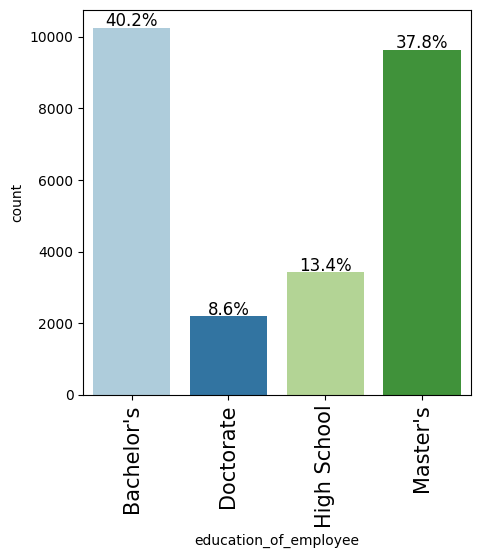

In [ ]:
# Using labeled barplot to get the observations on education
labeled_barplot(data, "education_of_employee");

- *We see that most of the candidates have a Bachelors's or Master's degree.*
- *The smallest group are candidates with a Doctorate with a High School eduction as next highest.*

#### Observations on region of employment

/tmp/ipython-input-16-3675549719.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


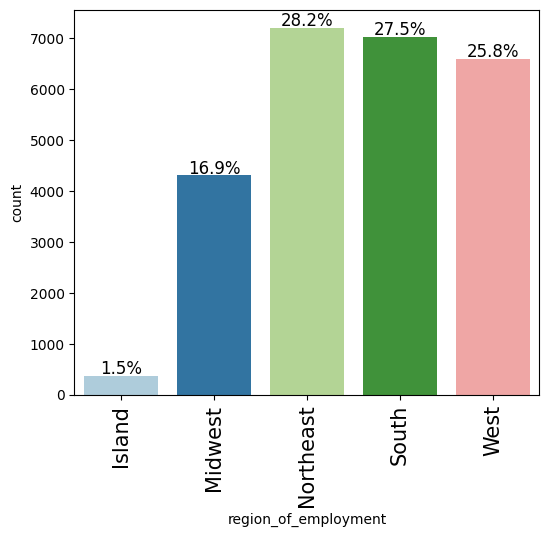

In [ ]:
# Using labeled barplot to get the observations on region of employment
labeled_barplot(data, "region_of_employment");

- *We observe that most of the candidates are for companies in Norhteast, South and West regions.*

#### Observations on job experience

/tmp/ipython-input-16-3675549719.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


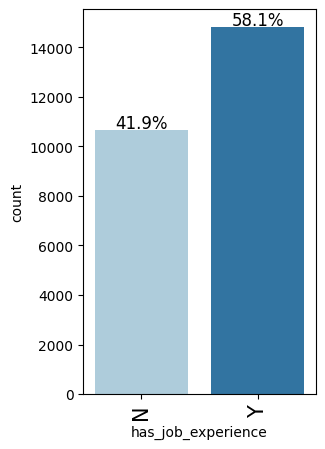

In [ ]:
# Using labeled barplot to get the observations on has_job_experience
labeled_barplot(data, "has_job_experience");

- *We see that 58 percent of the candidates have job experience.*

#### Observations on case status

/tmp/ipython-input-16-3675549719.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


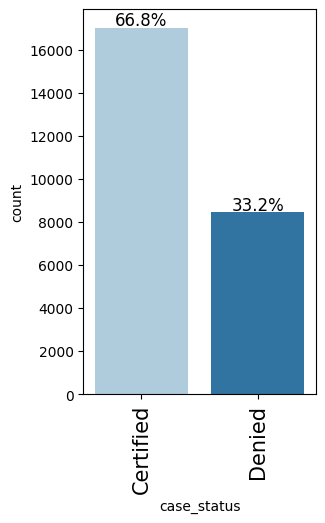

In [ ]:
# Using labeled barplot to get the observations on case_status
labeled_barplot(data, "case_status");

- *We observe that more than double the candidates (66 percent) have been certified when compared to the count of Denied candidates.*
- *So we see that this dataset is imbalanced with much more Certified candidates than Denied candidates.*

### Bivariate Analysis

**Creating functions that will help us with further analysis.**

In [ ]:
### function to plot distributions wrt target
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### Does higher education increase the chances of visa certification for well-paid jobs abroad?

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


<Figure size 1500x700 with 0 Axes>

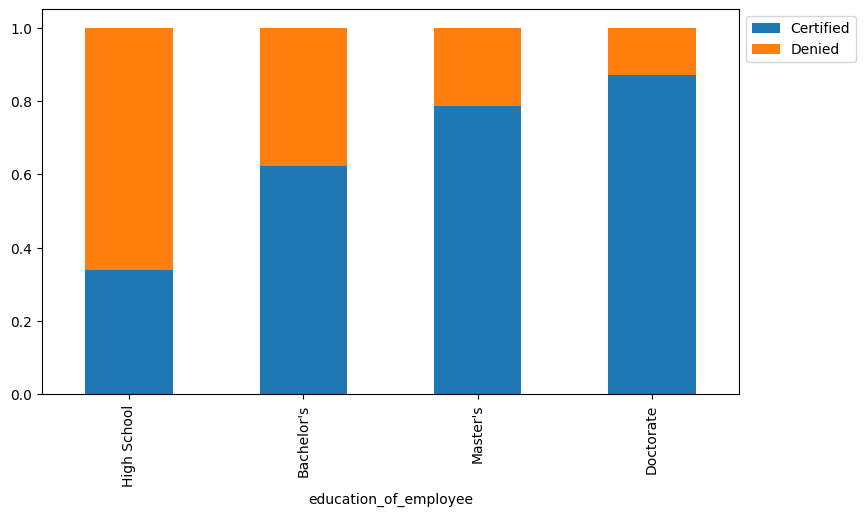

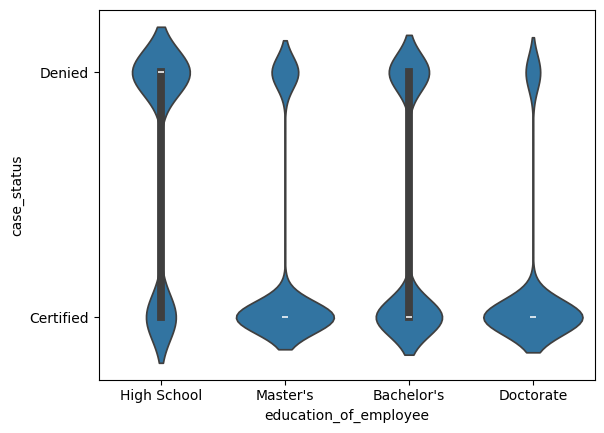

In [ ]:
# Viewing how these columns affect each other using stacked barplot
plt.figure(figsize=(15, 7))
stacked_barplot(data, "education_of_employee", "case_status")

# Using a violinplot to explore further
sns.violinplot(data=data, x='education_of_employee', y='case_status')
plt.show();

- *We do see that candidates with higher education are certified for work more than candidates with lower education levels.*
- *Candidates with higher education levels of Doctorate and Masters are more likely to be selected compared to candidates with High School or Bachelors.*
- *So higher education does increase the chances of visa certification.*
- *We also find that the largest number of applicants in this dataset have Bachelors degree (total of 10234) with Masters coming in second.*
- *This means are bachelors are the most preferred degree by employers in this dataset.*

#### How does visa status vary across different continents?

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


<Figure size 1500x700 with 0 Axes>

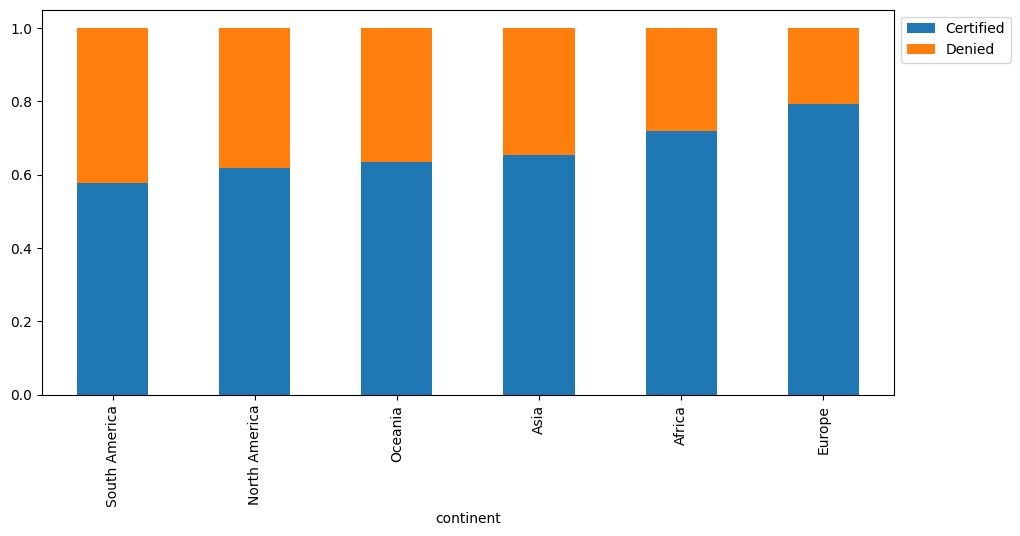

In [ ]:
# Viewing how these columns affect each other using stacked barplot
plt.figure(figsize=(15, 7))
stacked_barplot(data, "continent", "case_status")

- *We see that most of the applicants in this dataset are from Asia (16861) so that seems to be the most preferred continent for employers to recruit employees.*
- *We also see that candidates from Europe and Africa were more likely to be certified with the most percentage of candidates from those countries being certified.*
- *We see that candidates from South America had the least percentage of their visa applications certified.*  

#### Does having prior work experience influence the chances of visa certification for career opportunities abroad?

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


<Figure size 1500x700 with 0 Axes>

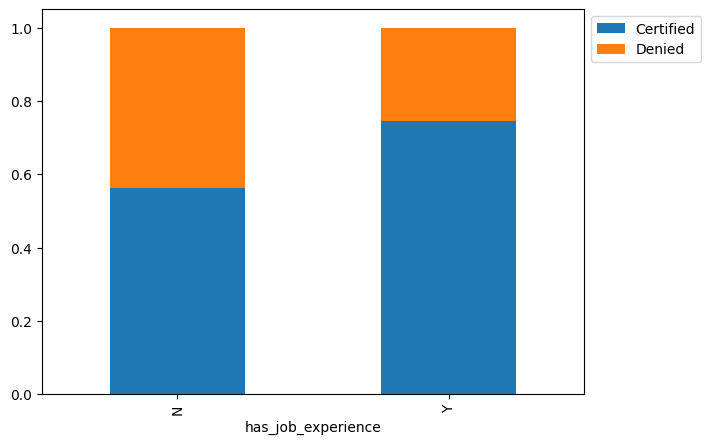

In [ ]:
# Viewing how these columns affect each other using stacked barplot
plt.figure(figsize=(15, 7))
stacked_barplot(data, "has_job_experience", "case_status")

- *We see that the dataset has more candidates with previous experience compared to candidates with no previous experience.*
- *We also see that a higher percentage of candidates with previous experience were certified compared to candidates with no previous experience.*
- *So having prior experience does increase the chances of visa certification.*

#### Is the prevailing wage consistent across all regions of the US?

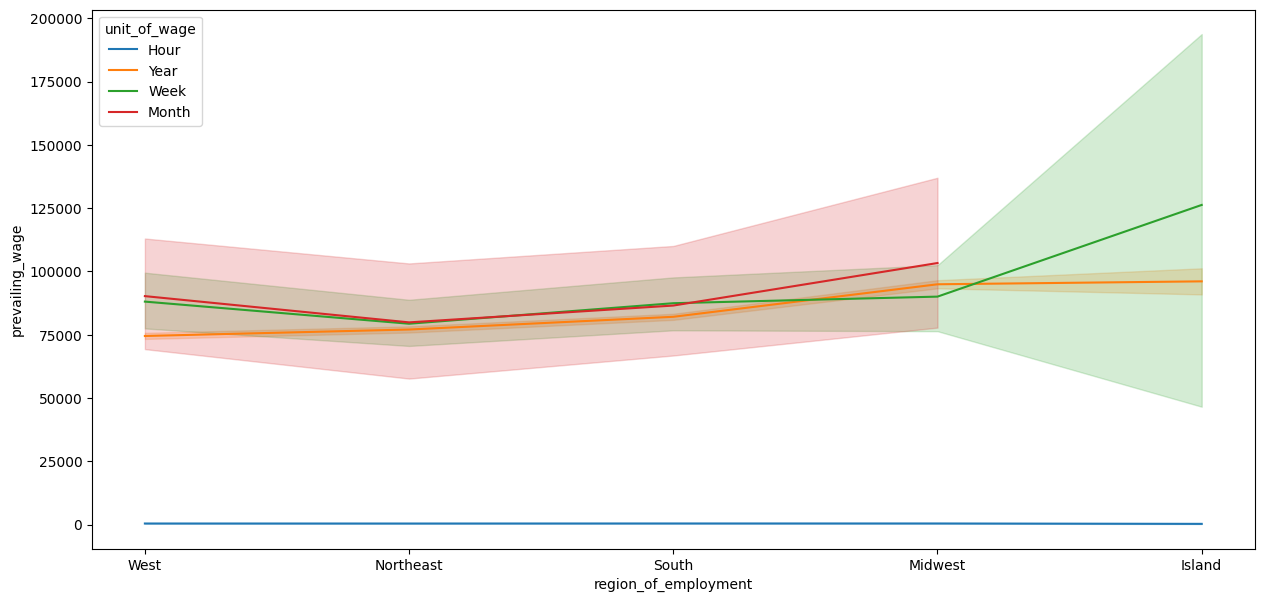

In [ ]:
# Using a line plot to explore this relation.
# since the unit of wage can be different for each row - setting Hue to unit of wage

plt.figure(figsize=(15, 7))
sns.lineplot(x='region_of_employment', y='prevailing_wage', data=data, hue="unit_of_wage")
plt.show()

- *The prevailing wage does vary across the various regions.*
- *The yearly wage is lowest in the West and highest in Midwest and Island. The yearly wage varies from around 75000 to around 100000 across all the regions.*
- *The weekly wage seems to be lowest in the Northeast and highest in Island.*
- *The monthly wage seems to be lowest in the Northeast and highest in Midwest with no monthly wages in Island. It varies between around 70000 to 125000.*
- *So prevailing wage does vary across various regions of the US but not by too much.*

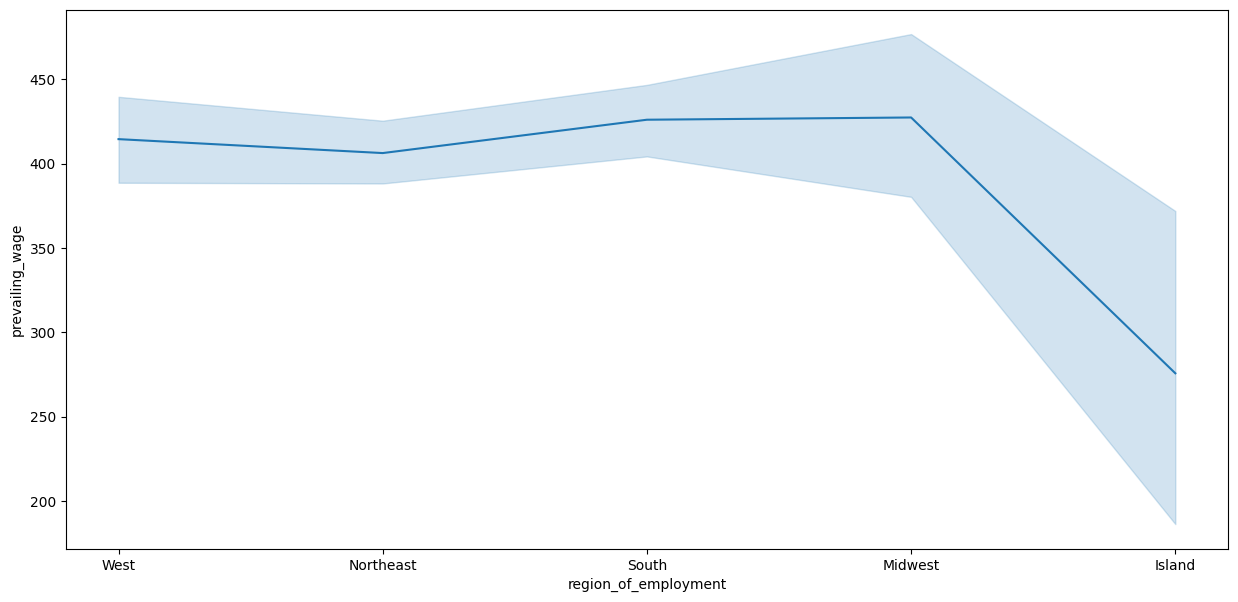

In [ ]:
# Since the hourly data is low across the regions -
# Isolating the hourly data into a separate dataframe
# to get more detailed information on it
data_hour = data[data["unit_of_wage"] == "Hour"]

plt.figure(figsize=(15, 7))
sns.lineplot(x='region_of_employment', y='prevailing_wage', data=data_hour)
plt.show()

- *We observe that the hourly data varies between around 370 and 500 across all the regions except Island region.*
- *The Island region has the lowest hourly wage while Midwest has the highest.*

-

#### Does visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?

/tmp/ipython-input-21-812524031.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")
/tmp/ipython-input-21-812524031.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


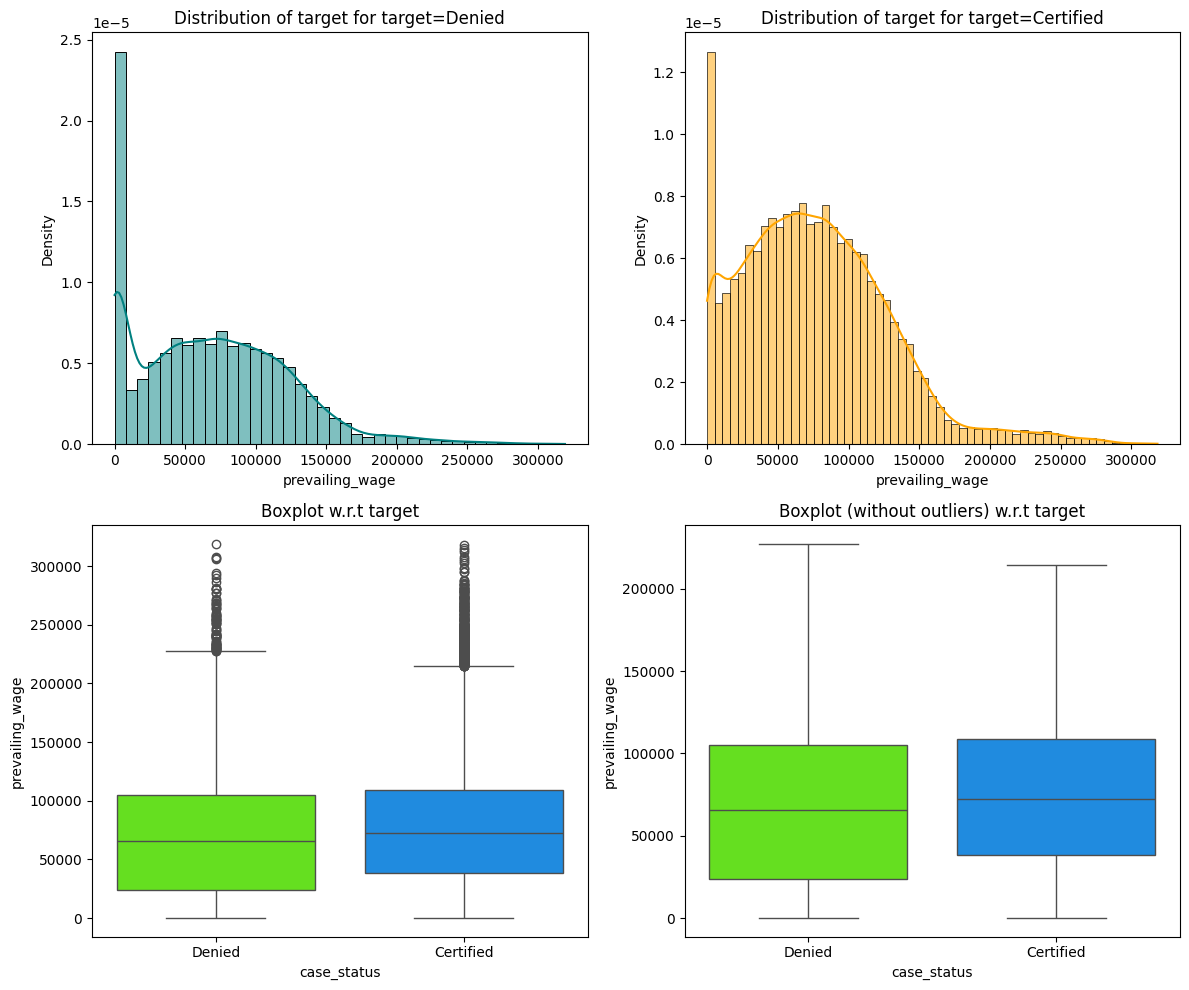

In [ ]:
# Using distribution_plot_wrt_target method to explore this relationship
distribution_plot_wrt_target(data,"prevailing_wage","case_status") ;

- *We observe that for both the certified and denied candidates, 75 percent of the candidates have prevailing wage less than around 120,000.*
- *We also see that for both the certified and denied candidates, there are many outliers in the prevailing wage.*
- *The outliers for both the certified and denied candidates are on the high side of wages starting from 210,000. So both the types are highly right skewed.*
- *We see that there is not too much variation in prevailing wages for both certified and denied candidates.*



#### Does the unit of prevailing wage (Hourly, Weekly, etc.) have any impact on the likelihood of visa application certification?

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


<Figure size 1500x700 with 0 Axes>

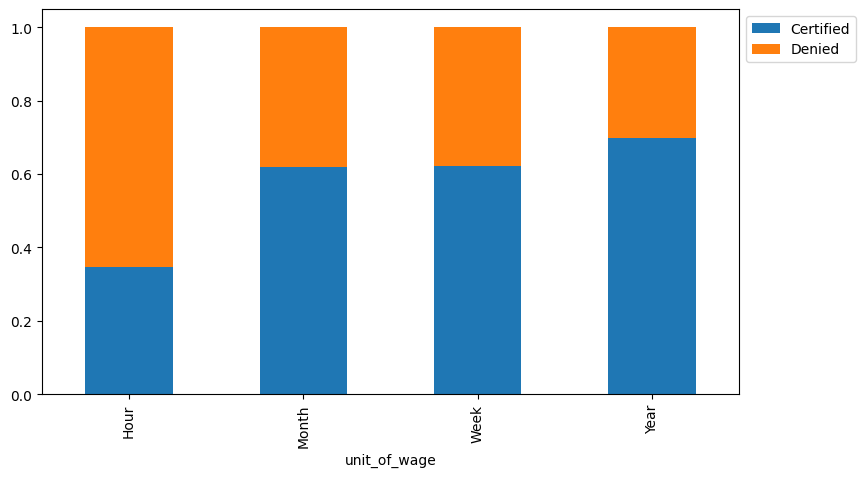

In [ ]:
# Viewing how these columns affect each other using stacked barplot
plt.figure(figsize=(15, 7))
stacked_barplot(data, "unit_of_wage", "case_status")

In [ ]:
# Using valuecounts to get the percentage count of the unit of wage
data["unit_of_wage"].value_counts(normalize=True)

,proportion
unit_of_wage,
Year,0.901177
Hour,0.084655
Week,0.010675
Month,0.003493


- *We see that candidates with yearly unit of wage are more likely to have their visa certified compared to other unit of wages.*
- *We also see that hourly candidates are more likely to be denied the visa.*
- *The monthly and weekly unit wage certification percentages are almost the same and fall between yearly and hourly.*

## Data Pre-processing

### Outlier Check

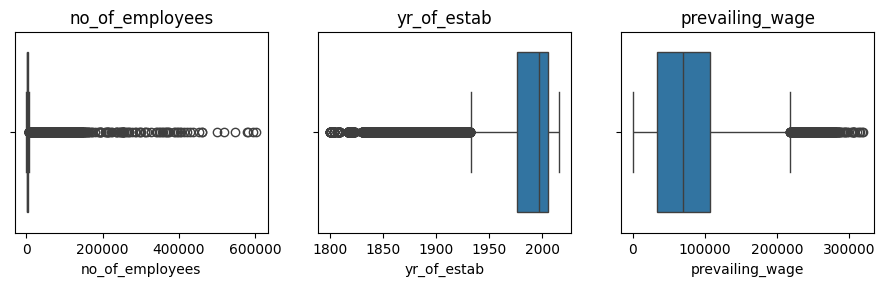

In [ ]:
# Getting numerical columns into a list
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

# Using boxplot to plot the boxplots of the numerical variables to see if they have outliers
for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i+1)
    sns.boxplot(data=data, x=variable)
    plt.title(variable)

plt.show()

- *We observe that number of employees is highly right skewed with lots of outliers.*
- *We also see that prevailing wage is also right skewed with many outliers.*
- *Year of establishment is left skewed with outliers.*


### Data Preparation for modeling

In [ ]:
# Checking for null values in columns  using isnull method and summing up for the columns.
print(data.isnull().sum())

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64


 - *None of the columns have any null values.*

In [ ]:

# Changing case_Status to 0 and 1 (1 for Certified and 0 for Denied)
data["case_status"] = data["case_status"].apply(lambda x: 1 if x == "Certified" else 0)


# Breaking up the data into X and y variables with X having the independant features
# and y containing the dependant variable.

# Removing columns case id and year of establishment of the company  as
# they dont add much value for the classification prediction in this data
# Also removing dependant variable case_status from X

X = data.drop(["case_id", "yr_of_estab", "case_status"], axis=1)

# Setting y to the dependant variable case_status
y = data["case_status"]

# Splitting data into train, validation and test set in a 70:15:15 ratio
# Using stratify to keep the same percentage of certified/denied in the train, val and test sets

# Doing initial split of train and temp 70 to 30
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Splitting the temp data into 2 equal halves to get the final split of 70:15:15
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


In [ ]:
# Getting counts of the data in all the sets

print("Shape of Training set : ", X_train.shape)
print("Shape of Validation set : ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

# Checking that 70 percent of rows are in training set
print("\nPercentage of rows in training set compared to total data:")
print(X_train.shape[0] / data.shape[0])

Shape of Training set :  (17836, 9)
Shape of Validation set :  (3822, 9)
Shape of test set :  (3822, 9)
Percentage of classes in training set:
case_status
1    0.667919
0    0.332081
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667713
0    0.332287
Name: proportion, dtype: float64

Percentage of rows in training set compared to total data:
0.7


In [ ]:
# One hot encoding the categorical data
# for the train, validation and test sets

X_train = pd.get_dummies(X_train, drop_first=True)
X_train = X_train.astype(float)

X_val = pd.get_dummies(X_val, drop_first=True)
X_val = X_val.astype(float)

X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.astype(float)

print(X_train.shape, X_val.shape, X_test.shape)

(17836, 20) (3822, 20) (3822, 20)


## Model Building

### Model Evaluation Criterion

- Choose the primary metric to evaluate the model on
- Elaborate on the rationale behind choosing the metric

**Model can make wrong predictions as:**
1. Predicting a candidate will be certified when in reality the candidate will be denied a job visa - This is a false positive and could lead to unworthy candidates getting selected. This could cause worthy candidates to be rejected due to visa limits.
2. Predicting a candidate will be denied while in reality the candidate will be certififed for the job visa - This is a false negative and the country could lose worthy talent.

**Which case is more important?**
* The objective from OFLC for using Machine learning was that they want ML to help them shortlist the candidates who have higher chances for VISA approval.
* We dont want to get unworthy candidates certified so we do want to reduce false positives.
* We also want to reduce false negatives as those candidates could also have a high chance of visa approval and we could lose them from the shortlist thus losing talented candidates.
* So both the above two cases are equally important and we want to minimize both of the above cases.
* So accuracy in prediction is the most important measure that we will track in our exercise.
* But since this dataset is imbalanced with 70 percent of the data being positive (certified) compared to Denied, we cannot rely on accuracy alone. So F1 score would be the best metric to track.
* So we will use F1 score along with accuracy as our model evaluation criteria.

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.
* The `model_performance_classification_sklearn` function will be used to check the model performance of models.
* The `confusion_matrix_sklearn` function will be used to plot the confusion matrix.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn

def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### Defining scorer to be used for cross-validation and hyperparameter tuning

In [ ]:
# Defining f1_score as the scorer
scorer = make_scorer(f1_score)


**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Model building with Original data

In [ ]:
# Lists to store models, model names and cv scores
models = []
results1 = []
names = []

# Appending models into the list
# Using BaggingClassifier with a DecisionTreeClassifier as estimator as first model
# Using RandomForestClassifier as second model
# Using GradientBoostingClassifier as third model
# Using AdaBoost as fourth model and XGBoost Classifier as fifth model
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("XGB", XGBClassifier(eval_metric='logloss', random_state=1)))

# Using stratified K-fold cross validation since we have an imbalanced data set
# Using 10 folds for Cross validation
for name, model in models:
    kfold = StratifiedKFold(
        n_splits=10, shuffle=True, random_state=1
    )
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train,scoring = scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{} CrossValidation Score: {}".format(name, cv_result.mean()))

print("\nTraining and  Validation F1 and accuracy scores:\n")

for name, model in models:
    model.fit(X_train, y_train)
    print("\n{} Train scores".format(name))
    print(model_performance_classification_sklearn(model, X_train, y_train))

    # Predicting on validation set
    print("\n{} Validation scores".format(name))
    print(model_performance_classification_sklearn(model, X_val, y_val))



Bagging CrossValidation Score: 0.7723072723801182
Random forest CrossValidation Score: 0.7913954347653438
Gradient Boosting CrossValidation Score: 0.8234936290720987
Adaboost CrossValidation Score: 0.8203115832090759
XGB CrossValidation Score: 0.8107511874970312

Training and  Validation F1 and accuracy scores:


Bagging Train scores
   Accuracy    Recall  Precision       F1
0  0.982395  0.982204   0.991358  0.98676

Bagging Validation scores
   Accuracy    Recall  Precision        F1
0  0.704605  0.783784   0.776183  0.779965

Random forest Train scores
   Accuracy  Recall  Precision        F1
0  0.999944     1.0   0.999916  0.999958

Random forest Validation scores
   Accuracy    Recall  Precision        F1
0  0.718472  0.827262   0.768839  0.796981

Gradient Boosting Train scores
   Accuracy    Recall  Precision        F1
0  0.758017  0.877613   0.785323  0.828907

Gradient Boosting Validation scores
   Accuracy   Recall  Precision        F1
0  0.744375  0.87309   0.773421  0.820239

In [ ]:
print("\nTraining and Validation F1 Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = f1_score(y_train, model.predict(X_train))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))


Training and Validation F1 Performance Difference:

Bagging: Training Score: 0.9868, Validation Score: 0.7800, Difference: 0.2068
Random forest: Training Score: 1.0000, Validation Score: 0.7970, Difference: 0.2030
Gradient Boosting: Training Score: 0.8289, Validation Score: 0.8202, Difference: 0.0087
Adaboost: Training Score: 0.8202, Validation Score: 0.8137, Difference: 0.0065
XGB: Training Score: 0.8746, Validation Score: 0.8142, Difference: 0.0604


- *We see that with these original models and without any hypertuning Gradient Boosting Classifier has the best scores (on accuracy and F1) on validation dataset.*
- *We see that XGB comes in second with on F1 and validation scores.*
- *We see that AdaBoost Classifier has come in third, with some overfitting.*
- *The above three models also have the best cross validation scores.*
- *We observe that RandomForest and BaggingClassifers (which have the best training scores) have the most overfitting and come in with the highest difference between training and validation scores.*


### Model Building with Oversampled data

In [ ]:
# Generating over samples using SMOTE
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

# Using SMOTE technique to create samples with k_neighbors value of 5
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After OverSampling, counts of label '1': {}".format(sum(y_train_over == 1)))
print("After OverSampling, counts of label '0': {} \n".format(sum(y_train_over == 0)))


print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before OverSampling, counts of label '1': 11913
Before OverSampling, counts of label '0': 5923 

After OverSampling, counts of label '1': 11913
After OverSampling, counts of label '0': 11913 

After OverSampling, the shape of train_X: (23826, 20)
After OverSampling, the shape of train_y: (23826,) 



- *We see that using the SMOTE technique has made the counts of Denied equal to the count of Certified, so that now we have same count of Certified and Denied data of 11913, by creating fake data for the Denied class.*

#### Testing with the same type of models on the oversampled data

In [ ]:
# Lists to store models, model names and cv scores
models = []
results1 = []
names = []

# Appending models into the list
# Using BaggingClassifier with a DecisionTreeClassifier as estimator as first model
# Using RandomForestClassifier as second model
# Using GradientBoostingClassifier as third model
# Using AdaBoost as fourth model and XGBoost Classifier as fifth model
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1), random_state=1)))
models.append(("Random Forest", RandomForestClassifier(random_state=1)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("XGB", XGBClassifier(eval_metric='logloss', random_state=1)))

# Using stratified K-fold cross validation since we have an imbalanced data set
# Using 10 folds for Cross validation
for name, model in models:
    kfold = StratifiedKFold(
        n_splits=10, shuffle=True, random_state=1
    )
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over, scoring = scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{} CrossValidation Score: {}".format(name, cv_result.mean()))

print("\nTraining and Validation Performance scores on Oversampled data:\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    print("\n{} Train scores".format(name))
    print(model_performance_classification_sklearn(model, X_train_over, y_train_over))

    # Predicting on validation set
    print("\n{} Validation scores".format(name))
    print(model_performance_classification_sklearn(model, X_val, y_val))


Bagging CrossValidation Score: 0.7689669560495476
Random Forest CrossValidation Score: 0.7896856955871503
Gradient Boosting CrossValidation Score: 0.8192843887130081
Adaboost CrossValidation Score: 0.8038319822608895
XGB CrossValidation Score: 0.8126811396934193

Training and Validation Performance scores on Oversampled data:


Bagging Train scores
   Accuracy    Recall  Precision      F1
0  0.986359  0.982036   0.990601  0.9863

Bagging Validation scores
   Accuracy    Recall  Precision        F1
0  0.694662  0.773991    0.77007  0.772026

Random Forest Train scores
   Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0

Random Forest Validation scores
   Accuracy    Recall  Precision        F1
0  0.715856  0.824912   0.767213  0.795017

Gradient Boosting Train scores
   Accuracy    Recall  Precision        F1
0  0.815202  0.867959   0.785118  0.824463

Gradient Boosting Validation scores
   Accuracy    Recall  Precision        F1
0  0.743328  0.859773   0.778921  0.8

In [ ]:
print("\nTraining and Validation F1 Performance Difference on OverSampled data:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = f1_score(y_train_over, model.predict(X_train_over))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))


Training and Validation F1 Performance Difference on OverSampled data:

Bagging: Training Score: 0.9863, Validation Score: 0.7720, Difference: 0.2143
Random Forest: Training Score: 1.0000, Validation Score: 0.7950, Difference: 0.2050
Gradient Boosting: Training Score: 0.8245, Validation Score: 0.8174, Difference: 0.0071
Adaboost: Training Score: 0.8108, Validation Score: 0.8077, Difference: 0.0031
XGB: Training Score: 0.8685, Validation Score: 0.8120, Difference: 0.0566


- *Looking at the results after oversampling, and checking validation dataset scores, we see that Gradient Boosting has the best F1 and accuracy scores.*
- *XGB comes in second on the validation dataset F1 and accuracy scores.*
- *Adaboost comes in third on the validation dataset scores.*
- *The cross validation scores are also higher for these 3 models.*
- *We observe that RandomForest and Bagging even though they have the best training scores have overfitted and have the lowest validation scores. They also have the highest difference between training and validation scores.*

### Model Building with Undersampled data

In [ ]:
# Using RandomUnderSampler for removing data
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)


print("Before UnderSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before UnderSampling, counts of label '0': {} \n".format(sum(y_train == 0)))


print("After UnderSampling, counts of label '1': {}".format(sum(y_train_un == 1)))
print("After UnderSampling, counts of label '0': {} \n".format(sum(y_train_un == 0)))


print("After UnderSampling, the shape of train_X: {}".format(X_train_un.shape))
print("After UnderSampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before UnderSampling, counts of label '1': 11913
Before UnderSampling, counts of label '0': 5923 

After UnderSampling, counts of label '1': 5923
After UnderSampling, counts of label '0': 5923 

After UnderSampling, the shape of train_X: (11846, 20)
After UnderSampling, the shape of train_y: (11846,) 



- *We see that the RandomUnderSampler has deleted some of the Certified data to make its count equal to that of the Denied class. Not both classes have the same count of 5923.*

#### Testing all the models on the Undersampled data

In [ ]:
# Lists to store models, model names and cv scores
models = []
results1 = []
names = []

# Appending models into the list
# Using BaggingClassifier with a DecisionTreeClassifier as estimator as first model
# Using RandomForestClassifier as second model
# Using GradientBoostingClassifier as third model
# Using AdaBoost as fourth model and XGBoost Classifier as fifth model
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("XGB", XGBClassifier(eval_metric='logloss', random_state=1)))

# Using stratified K-fold cross validation since we have an imbalanced data set
# Using 10 folds for Cross validation
for name, model in models:
    kfold = StratifiedKFold(
        n_splits=10, shuffle=True, random_state=1
    )
    cv_result = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un, scoring = scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{} CrossValidation Score: {}".format(name, cv_result.mean()))

print("\nTraining and Validation Performance scores on Undersampled data:\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    print("\n{} Train scores".format(name))
    print(model_performance_classification_sklearn(model, X_train_un, y_train_un))

    # Predicting on validation set
    print("\n{} Validation scores".format(name))
    print(model_performance_classification_sklearn(model, X_val, y_val))


Bagging CrossValidation Score: 0.6405512362358621
Random forest CrossValidation Score: 0.6643207916917183
Gradient Boosting CrossValidation Score: 0.7123495992376567
Adaboost CrossValidation Score: 0.7009430720568385
XGB CrossValidation Score: 0.6873702705513853

Training and Validation Performance scores on Undersampled data:


Bagging Train scores
   Accuracy    Recall  Precision        F1
0   0.97763  0.964714   0.990295  0.977337

Bagging Validation scores
   Accuracy    Recall  Precision        F1
0   0.65123  0.621622    0.81218  0.704238

Random forest Train scores
   Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0

Random forest Validation scores
   Accuracy    Recall  Precision        F1
0  0.677394  0.682335   0.804991  0.738605

Gradient Boosting Train scores
   Accuracy    Recall  Precision        F1
0   0.71999  0.738139   0.712284  0.724981

Gradient Boosting Validation scores
   Accuracy    Recall  Precision        F1
0  0.704082  0.726988    0.81048

In [ ]:
print("\nTraining and Validation F1 Performance Difference:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = f1_score(y_train_un, model.predict(X_train_un))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))


Training and Validation F1 Performance Difference:

Bagging: Training Score: 0.9809, Validation Score: 0.7720, Difference: 0.2089
Random forest: Training Score: 1.0000, Validation Score: 0.7950, Difference: 0.2050
Gradient Boosting: Training Score: 0.7421, Validation Score: 0.8174, Difference: -0.0752
Adaboost: Training Score: 0.7289, Validation Score: 0.8077, Difference: -0.0788
XGB: Training Score: 0.7959, Validation Score: 0.8120, Difference: -0.0161


- *Looking at the results after undersampling, and checking validation dataset scores, we see that again Gradient Boosting has the best F1 and accuracy scores.*
- *XGB comes in second on the validation dataset F1 and accuracy scores.*
- *Adaboost comes in third on the validation dataset scores.*
- *The above models also have the least difference between training and validation F1 and accuracy scores.*
- *We observe that RandomForest and Bagging even though they have the best training scores have overfitted and have the lowest validation scores.*
- *We will tune the best 3 models on the oversampled and undersampled datasets to find the best model and the best hyperparameters for it.*

## Hyperparameter Tuning

- *We see that in all our model testing on original, undersampled and oversampled datasets, Adaboost, GradientBoost and XGB have the best F1 and accuracy validation scores without any overfitting.*
- *We also noticed that RandomForest and BaggingClassifiers even though they have the best F1 and accuracy on the training set have the highest difference between training and validation F1 and accuracy scores and have overfitted.*
- *So we will tune these 3 models (Adaboost, GradientBoost and XGB) further using the oversampled and undersampled data and see which has the best scores.*

### Tuning Adaboost on oversampled data

**Best practices for hyperparameter tuning in AdaBoost:**

`n_estimators`:

- Start with a specific number (50 is used in general) and increase in steps: 50, 75, 85, 100

- Use fewer estimators (e.g., 50 to 100) if using complex base learners (like deeper decision trees)

- Use more estimators (e.g., 100 to 150) when learning rate is low (e.g., 0.1 or lower)

- Avoid very high values unless performance keeps improving on validation

`learning_rate`:

- Common values to try: 1.0, 0.5, 0.1, 0.01

- Use 1.0 for faster training, suitable for fewer estimators

- Use 0.1 or 0.01 when using more estimators to improve generalization

- Avoid very small values (< 0.01) unless you plan to use many estimators (e.g., >500) and have sufficient data


---

In [ ]:
ada_model = AdaBoostClassifier(random_state=1)

# For parameters based on the notes - Best practices for hyperparameter tuning in AdaBoost:
# Using n_estimators from 50 to 100 increased by 10
# Using learning_rate values suggested in the best practices
# AdaBoost uses DecisionTree as default estimator with max_depth of 1.
# Adding 2 more decision trees with max depth 2 and 3 to see if we can get better results.

param_grid = {
    "n_estimators": np.arange(50, 100, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}


# Using RandomizedSearchCV to search and get the best parameters for the F1 scorer
# We are using 50 iterations with n_jobs = -1 to run the models parallely
randomized_cv = RandomizedSearchCV(estimator=ada_model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(80), 'learning_rate': 1, 'estimator': DecisionTreeClassifier(max_depth=2, random_state=1)} with CV score=0.8124218169036477:


In [ ]:
# Get the best parameters
best_params = randomized_cv.best_params_

over_tuned_adb = AdaBoostClassifier(
    random_state=1,
    n_estimators = best_params['n_estimators'],
    learning_rate = best_params['learning_rate'],
    estimator= best_params['estimator'],
)
over_tuned_adb.fit(X_train_over, y_train_over)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                    random_state=1),
                   learning_rate=1, n_estimators=np.int64(80), random_state=1)

In [ ]:
# Checking model's performance on overtuned training set
adb_train = model_performance_classification_sklearn(over_tuned_adb, X_train_over, y_train_over)
adb_train

,Accuracy,Recall,Precision,F1
0,0.805087,0.851675,0.779083,0.813763


In [ ]:
# Checking model's performance on validation set
adb_val = model_performance_classification_sklearn(over_tuned_adb, X_val, y_val)
adb_val

,Accuracy,Recall,Precision,F1
0,0.733647,0.844888,0.776178,0.809077


### Tuning GradientBoostClassifier on oversampled data

**Best practices for hyperparameter tuning in Gradient Boosting:**

`n_estimators`:

* Start with 100 (default) and increase: 100, 200, 300, 500
* Typically, higher values lead to better performance, but they also increase training time
* Use 200–500 for larger datasets or complex problems
* Monitor validation performance to avoid overfitting, as too many estimators can degrade generalization


`learning_rate`:

* Common values to try: 0.1, 0.05, 0.01, 0.005
* Use lower values (e.g., 0.01 or 0.005) if you are using many estimators (e.g., > 200)
* Higher learning rates (e.g., 0.1) can be used with fewer estimators for faster convergence
* Always balance the learning rate with `n_estimators` to prevent overfitting or underfitting


`subsample`:

* Common values: 0.7, 0.8, 0.9, 1.0
* Use a value between `0.7` and `0.9` for improved generalization by introducing randomness
* `1.0` uses the full dataset for each boosting round, potentially leading to overfitting
* Reducing `subsample` can help reduce overfitting, especially in smaller datasets


`max_features`:

* Common values: `"sqrt"`, `"log2"`, or float (e.g., `0.3`, `0.5`)
* `"sqrt"` (default) works well for classification tasks
* Lower values (e.g., `0.3`) help reduce overfitting by limiting the number of features considered at each split

---

In [ ]:
# Creating model
GB_Model = GradientBoostingClassifier(random_state=1)

# We will define the below parameters based on the
# guidance in the Best practices for hyperparameter tuning in Gradient Boosting: notes section
param_grid = {
    "n_estimators": np.arange(200,500,25),
    "learning_rate": [0.01, 0.001, 0.05, .005],
    "subsample":[0.7,0.8,0.9],
    "max_features":[0.3,0.5,0.7]
}

# Using RandomizedSearchCV to search and get the best parameters for the F1 scorer
# We are using 50 iterations with n_jobs = -1 to run the models parallely
randomized_cv = RandomizedSearchCV(estimator=GB_Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=-1, n_jobs = 1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.8, 'n_estimators': np.int64(425), 'max_features': 0.3, 'learning_rate': 0.05} with CV score=0.8177901446395766:


In [ ]:
# Get the best parameters
best_params = randomized_cv.best_params_

over_tuned_gbc = GradientBoostingClassifier(
    random_state=1,
    n_estimators =  best_params['n_estimators'],
    learning_rate =  best_params['learning_rate'],
    subsample = best_params['subsample'],
    max_features = best_params['max_features']
)
over_tuned_gbc.fit(X_train_over, y_train_over)

GradientBoostingClassifier(learning_rate=0.05, max_features=0.3,
                           n_estimators=np.int64(425), random_state=1,
                           subsample=0.8)

In [ ]:
# Checking model's performance on overtuned training set
gbc_train = model_performance_classification_sklearn(over_tuned_gbc, X_train_over, y_train_over)
gbc_train

,Accuracy,Recall,Precision,F1
0,0.817636,0.868967,0.788063,0.82654


In [ ]:
# Checking model's performance on validation set
gbc_val = model_performance_classification_sklearn(over_tuned_gbc, X_val, y_val)
gbc_val

,Accuracy,Recall,Precision,F1
0,0.744375,0.860165,0.77983,0.818029


### Tuning GradientBoostClassifier on undersampled data

In [ ]:
# Creating model
GB_Model = GradientBoostingClassifier(random_state=1)

# We will define the below parameters based on the
# guidance in the Best practices for hyperparameter tuning in Gradient Boosting: notes section
param_grid = {
    "n_estimators": np.arange(100,200,10),
    "learning_rate": [0.01, 0.05, .1],
    "subsample":[0.7,0.8],
    "max_features":[0.3,0.5]
}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=GB_Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = 1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': np.int64(110), 'max_features': 0.3, 'learning_rate': 0.01} with CV score=0.7206801845218758:


In [ ]:
# Get the best parameters
best_params = randomized_cv.best_params_

under_tuned_gbc = GradientBoostingClassifier(
    random_state=1,
    n_estimators =  best_params['n_estimators'],
    learning_rate =  best_params['learning_rate'],
    subsample = best_params['subsample'],
    max_features = best_params['max_features']
)
under_tuned_gbc.fit(X_train_un, y_train_un)

GradientBoostingClassifier(learning_rate=0.01, max_features=0.3,
                           n_estimators=np.int64(110), random_state=1,
                           subsample=0.7)

In [ ]:
# Checking model's performance on undertuned training set
gbc_train_un = model_performance_classification_sklearn(under_tuned_gbc, X_train_un, y_train_un)
gbc_train_un

,Accuracy,Recall,Precision,F1
0,0.695087,0.790647,0.663785,0.721683


In [ ]:
# Checking model's performance on validation set
gbc_val_un = model_performance_classification_sklearn(under_tuned_gbc, X_val, y_val)
gbc_val_un

,Accuracy,Recall,Precision,F1
0,0.713501,0.784175,0.786332,0.785252


### Tuning XGBClassifier on oversampled data

**Best practices for hyperparameter tuning in XGBoost:**

`n_estimators`:

* Start with 50 and increase in steps: 50,75,100,125.
* Use more estimators (e.g., 150-250) when using lower learning rates
* Monitor validation performance
* High values improve learning but increase training time

`subsample`:

* Common values: 0.5, 0.7, 0.8, 1.0
* Use `0.7–0.9` to introduce randomness and reduce overfitting
* `1.0` uses the full dataset in each boosting round; may overfit on small datasets
* Values < 0.5 are rarely useful unless dataset is very large

`gamma`:

* Try values: 0 (default), 1, 3, 5, 8
* Controls minimum loss reduction needed for a split
* Higher values make the algorithm more conservative (i.e., fewer splits)
* Use values > 0 to regularize and reduce overfitting, especially on noisy data


`colsample_bytree`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled per tree
* Lower values (e.g., 0.3 or 0.5) increase randomness and improve generalization
* Use `1.0` when you want all features considered for every tree


`colsample_bylevel`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled at each tree level (i.e., per split depth)
* Lower values help in regularization and reducing overfitting
* Often used in combination with `colsample_bytree` for fine control over feature sampling

---

In [ ]:
# Creating XGB Model
model = XGBClassifier(random_state=1,eval_metric='logloss')

# We will define the below parameters based on the
# guidance in the Best practices for hyperparameter tuning in XGBoost notes section
param_grid={
    'n_estimators': np.arange(50,200,25),
    'subsample': [0.5, 0.7, 0.8, 1.0],
    'gamma': [1, 3, 5, 8],
    'colsample_bytree': [0.3, 0.5, 0.7, 1.0],
    'colsample_bylevel': [0.3, 0.5, 0.7, 1.0]
}

# Using RandomizedSearchCV to search and get the best parameters for the F1 scorer
# We are using 50 iterations with n_jobs = -1 to run the models parallely
randomized_cv = RandomizedSearchCV( estimator=model, param_distributions=param_grid, n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 1.0, 'n_estimators': np.int64(100), 'gamma': 8, 'colsample_bytree': 0.3, 'colsample_bylevel': 0.7} with CV score=0.8202947955367514:


In [ ]:
# Get the best parameters
best_params = randomized_cv.best_params_

over_tuned_xgb = XGBClassifier(
    random_state=1,
    n_estimators = best_params['n_estimators'],
    subsample = best_params['subsample'],
    gamma = best_params['gamma'],
    colsample_bytree = best_params['colsample_bytree'],
    colsample_bylevel = best_params['colsample_bylevel']
)
over_tuned_xgb.fit(X_train_over, y_train_over)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.7, colsample_bynode=None,
              colsample_bytree=0.3, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=8, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(100), n_jobs=None,
              num_parallel_tree=None, random_state=1, ...)

In [ ]:
# Checking model's performance on overtuned training set
xgb_train = model_performance_classification_sklearn(over_tuned_xgb, X_train_over, y_train_over)
xgb_train

,Accuracy,Recall,Precision,F1
0,0.811215,0.871485,0.777736,0.821946


In [ ]:
# Checking model's performance on overtuned training set
xgb_val = model_performance_classification_sklearn(over_tuned_xgb, X_val, y_val)
xgb_val

,Accuracy,Recall,Precision,F1
0,0.742805,0.86604,0.775245,0.818131


### Tuning XGBClassifier on undersampled data

In [ ]:
# Creating XGB Model
model = XGBClassifier(random_state=1,eval_metric='logloss')

# We will define the below parameters based on the
# guidance in the Best practices for hyperparameter tuning in XGBoost notes section
param_grid={
    'n_estimators': np.arange(50,200,25),
    'subsample': [0.5, 0.7, 0.8, 1.0],
    'gamma': [1, 3, 5, 8],
    'colsample_bytree': [0.3, 0.5, 0.7, 1.0],
    'colsample_bylevel': [0.3, 0.5, 0.7, 1.0]
}

# Using RandomizedSearchCV to search and get the best parameters for the F1 scorer
# We are using 50 iterations with n_jobs = -1 to run the models parallely
randomized_cv = RandomizedSearchCV( estimator=model, param_distributions=param_grid, n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.8, 'n_estimators': np.int64(100), 'gamma': 8, 'colsample_bytree': 1.0, 'colsample_bylevel': 1.0} with CV score=0.7218632811411524:


In [ ]:
# Get the best parameters
best_params = randomized_cv.best_params_

under_tuned_xgb = XGBClassifier(
    random_state=1,
    n_estimators = best_params['n_estimators'],
    subsample = best_params['subsample'],
    gamma = best_params['gamma'],
    colsample_bytree = best_params['colsample_bytree'],
    colsample_bylevel = best_params['colsample_bylevel']
)
under_tuned_xgb.fit(X_train_un, y_train_un)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=1.0, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=8, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(100), n_jobs=None,
              num_parallel_tree=None, random_state=1, ...)

In [ ]:
# Checking model's performance on overtuned training set
xgb_train_un = model_performance_classification_sklearn(under_tuned_xgb, X_train_un, y_train_un)
xgb_train_un

,Accuracy,Recall,Precision,F1
0,0.710366,0.750633,0.694688,0.721578


In [ ]:
# Checking model's performance on overtuned training set
xgb_val_un = model_performance_classification_sklearn(under_tuned_xgb, X_val, y_val)
xgb_val_un

,Accuracy,Recall,Precision,F1
0,0.716379,0.75284,0.809263,0.780032


## Model Performance Summary and Final Model Selection

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        gbc_train_un.T,
        gbc_train.T,
        xgb_train_un.T,
        xgb_train.T,
        adb_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "GradientBoost trained on Undersampled data",
    "GradientBoost trained on Oversampled data",
    "XGB trained on Undersampled data",
    "XGB trained on Oversampled data",
    "AdaBoost trained on Oversampled data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,GradientBoost trained on Undersampled data,GradientBoost trained on Oversampled data,XGB trained on Undersampled data,XGB trained on Oversampled data,AdaBoost trained on Oversampled data
Accuracy,0.695087,0.817636,0.710366,0.811215,0.805087
Recall,0.790647,0.868967,0.750633,0.871485,0.851675
Precision,0.663785,0.788063,0.694688,0.777736,0.779083
F1,0.721683,0.826540,0.721578,0.821946,0.813763


In [ ]:
# validation performance comparison
models_val_comp_df = pd.concat(
    [
        gbc_val_un.T,
        gbc_val.T,
        xgb_val_un.T,
        xgb_val.T,
        adb_val.T
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "GradientBoost tuned on Undersampled data",
    "GradientBoost on Oversampled data",
    "XGB on Undersampled data",
    "XGB on Oversampled data",
    "AdaBoost on Oversampled data",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,GradientBoost tuned on Undersampled data,GradientBoost on Oversampled data,XGB on Undersampled data,XGB on Oversampled data,AdaBoost on Oversampled data
Accuracy,0.713501,0.744375,0.716379,0.742805,0.733647
Recall,0.784175,0.860165,0.752840,0.866040,0.844888
Precision,0.786332,0.779830,0.809263,0.775245,0.776178
F1,0.785252,0.818029,0.780032,0.818131,0.809077


- *Comparing F1 scores on validation sets, we see that XGB on the Oversampled data has the best performance on the  validation set with GradientBoost on Oversampled data coming a close second.*
- *Comparing F1 scores on training set, we see that GradientBoost on Oversampled model has a slightly better performance on the training set compared to XGB on OverSampled data.*
- *There is not much of a difference between the two, but we will go with the XGB on Oversampled model, since it has the best performance on the validation set.*

In [ ]:
# Let's check the final model performance on test set
ada_test = model_performance_classification_sklearn(over_tuned_xgb, X_test, y_test)
ada_test

,Accuracy,Recall,Precision,F1
0,0.742543,0.867555,0.774126,0.818182


- *The scores on the test set are in line with the F1 and accuracy scores we achieved with this model on the validation set also.*

## Actionable Insights and Recommendations

* Considering the models we built, we can see that the Boosting models are better at predicting without overfitting compared to the Bagging models, before any tuning is done.
* We also see that oversampling models give slightly better performance on training and validation data compared to the undersampling ones, probably because they are trained on more data.
* Since the objective is to help in shortlisting the candidates having higher chances of Visa approval, we could predict the probability of selection using predict_proba method of the selected XGBoost model. If the probability of approval is greater than 80 percent, those candidates alone could be vetted by OFLC staff to make sure they are good candidates for visa approval thus reducing the workload for the staff.
* Since we saw from the EDA analysis that candidates with higher education are more likely to be selected, the OFLC staff could reduce processing times for these candidates (if the model selects them) to just checking their wages are in check with the prevailing wage for the position.
* Similarly since Asia has the most number of candidates that are applying, the selected model could be fine-tuned further with results from Asia, to see if we can improve F1 scores for Asian candidates further to help reduce the workload for OFLC staff.
* We found that unit of wage yearly makes up 90 percent of the data and the yearly candidates had the most Certified candidates compared to other unit of wage. So we could fine tune our model to increase yearly unit of wage F1 prediction scores maybe by creating oversamples for yearly unit of wage. This could also reduce workload for staff.

<font size=6 color='blue'>Power Ahead</font>
___